In [ ]:
pip install tensorflow-addons

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 612.1/612.1 kB 5.2 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from pandas import read_csv
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten, LSTM, RepeatVector, Input, BatchNormalization, ReLU, ELU, LeakyReLU, Bidirectional, GRU
from keras.layers.convolutional import Conv1D, MaxPooling1D, Conv2D, MaxPooling2D, AveragePooling2D
from keras.models import Model
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import KFold, RepeatedKFold, RandomizedSearchCV, RepeatedStratifiedKFold
from tensorflow import keras
from sklearn.model_selection import cross_val_score
from keras.layers import concatenate, add
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow_addons.layers import GroupNormalization

In [ ]:
import tensorflow as tf
from tensorflow.python.keras import backend as K

# adjust values to your needs
config = tf.compat.v1.ConfigProto( device_count = {'GPU': 1} )
sess = tf.compat.v1.Session(config=config)
K.set_session(sess)

In [ ]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ids_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Conference and Journal/2023/TNSE/Dataset/NIDD_5G_Cleaned_9_Classes_NaN_Removed.csv')

In [ ]:
ids_data.head()

,Unnamed: 0,Seq,Dur,RunTime,Mean,Sum,Min,Max,Proto,Cause,...,DstLoss,pLoss,Rate,SrcRate,DstRate,State,TcpRtt,SynAck,AckDat,Attack Type
0,0,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2,1,...,0,0.0,0.000000,0.000000,0.000000,5,0.0,0.0,0.0,0
1,1,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2,1,...,0,0.0,0.000000,0.000000,0.000000,5,0.0,0.0,0.0,0
2,2,3,4.998020,4.998020,4.998020,4.998020,4.998020,4.998020,0,1,...,0,0.0,42.616875,39.015450,3.401347,2,0.0,0.0,0.0,0
3,3,4,4.998037,4.998037,4.998037,4.998037,4.998037,4.998037,0,1,...,0,0.0,36.614376,32.412727,4.001571,2,0.0,0.0,0.0,0
4,4,5,4.999453,4.999453,4.999453,4.999453,4.999453,4.999453,0,1,...,0,0.0,44.404858,40.604443,3.600394,2,0.0,0.0,0.0,0


In [ ]:
ids_data = ids_data.drop('Unnamed: 0',axis=1)

In [ ]:
ids_data['Attack Type'].value_counts()

0    477737
1    457340
2    140812
3     73124
4     20052
5     20043
6     15906
7      9721
8      1155
Name: Attack Type, dtype: int64

In [ ]:
print(ids_data.dtypes)

Seq              int64
Dur            float64
RunTime        float64
Mean           float64
Sum            float64
Min            float64
Max            float64
Proto            int64
Cause            int64
TotPkts          int64
SrcPkts          int64
DstPkts          int64
TotBytes         int64
SrcBytes         int64
DstBytes         int64
Offset           int64
sMeanPktSz     float64
dMeanPktSz     float64
Load           float64
SrcLoad        float64
DstLoad        float64
Loss             int64
SrcLoss          int64
DstLoss          int64
pLoss          float64
Rate           float64
SrcRate        float64
DstRate        float64
State            int64
TcpRtt         float64
SynAck         float64
AckDat         float64
Attack Type      int64
dtype: object


In [ ]:
ids_data.shape

(1215890, 33)

In [ ]:
features = []
for feature in ids_data.columns:
    if feature != 'Attack Type':
        features.append(feature)
x_ids = ids_data[features]
y_ids = ids_data['Attack Type']

In [ ]:
from sklearn.preprocessing import MinMaxScaler
#Normalization using MinMaxScaller
scaler = MinMaxScaler()
scaled_x_ids = scaler.fit_transform(x_ids)

In [ ]:
x_ids_train, x_ids_test, y_ids_train, y_ids_test = train_test_split(scaled_x_ids, y_ids, test_size=0.3, random_state=42, shuffle=True, stratify=y_ids)

In [ ]:
y_ids_train = to_categorical(y_ids_train)
y_ids_train.shape

(851123, 9)

In [ ]:
y_ids_test = to_categorical(y_ids_test)
y_ids_test.shape

(364767, 9)

In [ ]:
scaled_x_ids_train = np.array(x_ids_train)
y_ids_train = np.array(y_ids_train)
scaled_x_ids_train.shape

(851123, 32)

In [ ]:
scaled_x_ids_test = np.array(x_ids_test)
y_ids_test = np.array(y_ids_test)
scaled_x_ids_test.shape

(364767, 32)

In [ ]:
scaled_x_ids_train.shape, y_ids_train.shape

((851123, 32), (851123, 9))

In [ ]:
scaled_x_ids_test.shape, y_ids_test.shape

((364767, 32), (364767, 9))

In [ ]:
scaled_x_ids_train = scaled_x_ids_train.reshape(scaled_x_ids_train.shape[0], 1, 32, 1)

In [ ]:
scaled_x_ids_test = scaled_x_ids_test.reshape(scaled_x_ids_test.shape[0], 1, 32, 1)

In [ ]:
opt = keras.optimizers.Adam(learning_rate=0.001)

In [ ]:
import tensorflow as tf
import keras
my_metrics = [
      tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
      tf.keras.metrics.Precision(name='precision'),
      tf.keras.metrics.Recall(name="recall")
]

In [ ]:
def FBC(d_input):
  conv_1 = Conv2D(8, kernel_size=(1,3), padding='same', strides=(1,1))(d_input)
  batch_1 = BatchNormalization()(conv_1)
  relu_1 = Activation('relu')(batch_1)
  conv_2 = Conv2D(8, kernel_size=(3,1), padding='same', strides=(1,1))(relu_1)
  batch_2 = BatchNormalization()(conv_2)
  relu_2 = Activation('relu')(batch_2)
  pool_1 = MaxPooling2D(pool_size=(2,2), padding='same')(relu_2)
  return pool_1

In [ ]:
def PDC(d_input):
  conv_1 = Conv2D(8, kernel_size=(1,3), padding='same', strides=(1,1))(d_input)
  batch_1 = BatchNormalization()(conv_1)
  relu_1 = Activation('relu')(batch_1)
  conv_2 = Conv2D(8, kernel_size=(1,3), groups=4, padding='same', strides=(1,1))(relu_1)
  batch_2 = GroupNormalization(groups=4)(conv_2)
  relu_2 = Activation('relu')(batch_2)
  conv_3 = Conv2D(8, kernel_size=(3,1), groups=4, padding='same', strides=(1,1))(relu_1)
  batch_3 = GroupNormalization(groups=4)(conv_3)
  relu_3 = Activation('relu')(batch_3)
  merge_1 = concatenate([relu_2, relu_3])
  pool_1 = MaxPooling2D(pool_size=(2,2), padding="same")(merge_1)
  conv_4 = Conv2D(8, kernel_size=(1,1), padding='same', strides=(1,1))(pool_1)
  batch_4 = BatchNormalization()(conv_4)
  relu_4 = Activation('relu')(batch_4)
  conv_5 = Conv2D(8, kernel_size=(1,1), padding='same', strides=(1,1))(relu_1)
  batch_5 = BatchNormalization()(conv_5)
  relu_5 = Activation('relu')(batch_5)
  pool_2 = MaxPooling2D(pool_size=(2,2), padding="same")(relu_5)
  add_1 = add([relu_4, pool_2])
  return add_1

In [ ]:
def MetaIDS():
  data_input = Input(shape=(1, 32, 1))
  fbc = FBC(data_input)
  pdc = PDC(fbc)
  pool_1 = AveragePooling2D(pool_size=(2,2), padding='same')(pdc)
  flat_1 = Flatten()(pool_1)
  hidden_1 = Dense(10, activation='relu')(flat_1)
  hidden_2 = Dense(20, activation='relu')(hidden_1)
  hidden_3 = Dense(10, activation='relu')(hidden_2)
  data_output = Dense(9, activation='softmax')(hidden_3)
  model = Model(inputs=data_input, outputs=data_output)
  return model

In [ ]:
model = MetaIDS()

In [ ]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 1, 32, 1)]   0           []                               
                                                                                                  
 conv2d (Conv2D)                (None, 1, 32, 8)     32          ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 1, 32, 8)    32          ['conv2d[0][0]']                 
 alization)                                                                                       
                                                                                                  
 activation (Activation)        (None, 1, 32, 8)     0           ['batch_normalization[0][0]']

In [ ]:
 model.compile(optimizer=opt, loss=tf.keras.losses.CategoricalCrossentropy(), metrics=my_metrics)

In [ ]:
model_his = model.fit(scaled_x_ids_train, y_ids_train, batch_size=32, epochs=5, validation_data=(scaled_x_ids_test, y_ids_test))

Epoch 1/5
26598/26598 [==============================] - 463s 17ms/step - loss: 0.0649 - accuracy: 0.9790 - precision: 0.9837 - recall: 0.9763 - val_loss: 0.0781 - val_accuracy: 0.9764 - val_precision: 0.9776 - val_recall: 0.9753
Epoch 2/5
26598/26598 [==============================] - 429s 16ms/step - loss: 0.0326 - accuracy: 0.9885 - precision: 0.9888 - recall: 0.9883 - val_loss: 0.0749 - val_accuracy: 0.9652 - val_precision: 0.9656 - val_recall: 0.9648
Epoch 3/5
26598/26598 [==============================] - 426s 16ms/step - loss: 0.0271 - accuracy: 0.9905 - precision: 0.9908 - recall: 0.9904 - val_loss: 0.0255 - val_accuracy: 0.9906 - val_precision: 0.9909 - val_recall: 0.9904
Epoch 4/5
26598/26598 [==============================] - 434s 16ms/step - loss: 0.0238 - accuracy: 0.9918 - precision: 0.9920 - recall: 0.9916 - val_loss: 0.0308 - val_accuracy: 0.9896 - val_precision: 0.9898 - val_recall: 0.9894
Epoch 5/5
26598/26598 [==============================] - 465s 17ms/step - loss: 

In [ ]:
scores = model.evaluate(scaled_x_ids_test, y_ids_test, verbose=2)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))
print("%s: %.3f" % (model.metrics_names[0], scores[0]))

11399/11399 - 45s - loss: 0.0391 - accuracy: 0.9839 - precision: 0.9841 - recall: 0.9837 - 45s/epoch - 4ms/step
accuracy: 98.39%
loss: 0.039


In [ ]:
import time
start_model = time.time()
model.evaluate(scaled_x_ids_test, y_ids_test, batch_size=32)
end_model = time.time()
total_time_model = (end_model - start_model) / scaled_x_ids_test.shape[0]
print(total_time_model)

11399/11399 [==============================] - 55s 5ms/step - loss: 0.0391 - accuracy: 0.9839 - precision: 0.9841 - recall: 0.9837
0.00015003131482890634


11399/11399 [==============================] - 49s 4ms/step


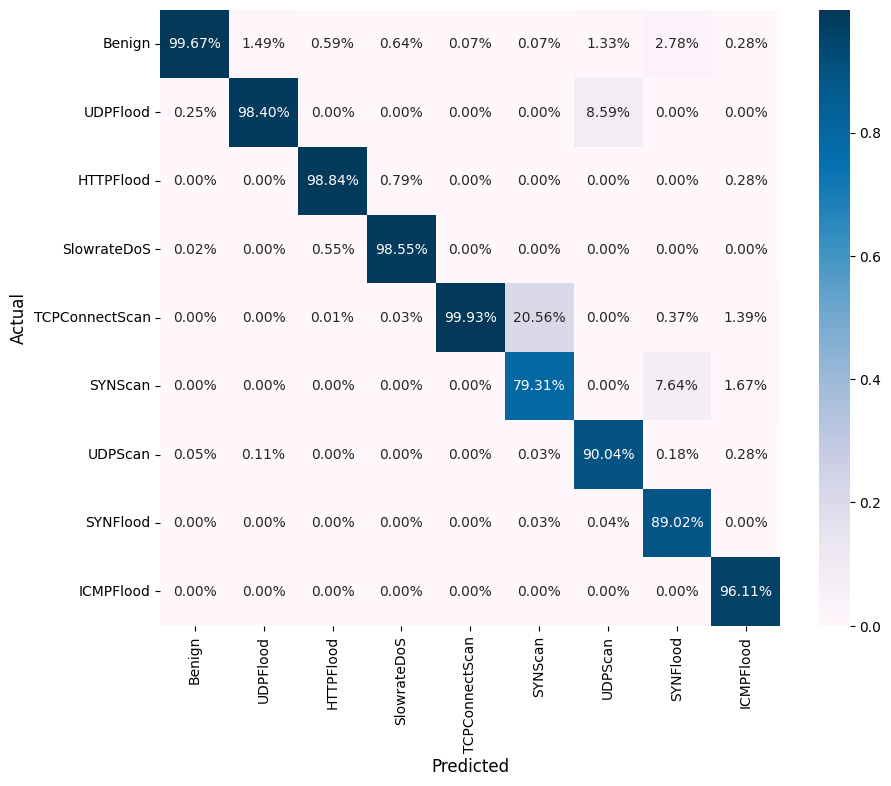

In [ ]:
from sklearn.metrics import confusion_matrix, multilabel_confusion_matrix
import pandas as pd
predictions = model.predict(scaled_x_ids_test)
y_pred = np.argmax(predictions, axis=-1)
y_true=np.argmax(y_ids_test, axis=-1)
df_cm = pd.DataFrame(confusion_matrix(y_true, y_pred), index=["Benign","UDPFlood","HTTPFlood","SlowrateDoS","TCPConnectScan","SYNScan","UDPScan","SYNFlood","ICMPFlood"], columns=["Benign","UDPFlood","HTTPFlood","SlowrateDoS","TCPConnectScan","SYNScan","UDPScan","SYNFlood","ICMPFlood"])
fig = plt.figure(figsize=(10, 8))
ax= plt.subplot()
sns.heatmap(df_cm/np.sum(df_cm), annot=True, ax = ax, fmt = '.2%', cmap="PuBu")
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
plt.show()

11399/11399 [==============================] - 49s 4ms/step


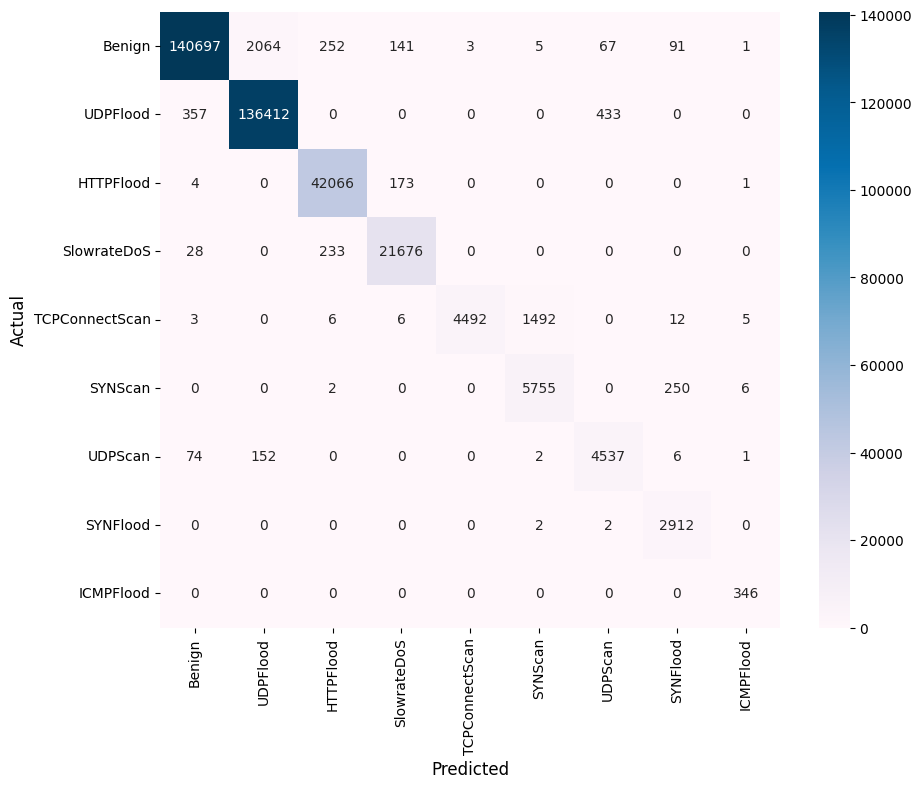

In [ ]:
from sklearn.metrics import confusion_matrix, multilabel_confusion_matrix
import pandas as pd
predictions = model.predict(scaled_x_ids_test)
y_pred = np.argmax(predictions, axis=-1)
y_true=np.argmax(y_ids_test, axis=-1)
df_cm = pd.DataFrame(confusion_matrix(y_true, y_pred), index=["Benign","UDPFlood","HTTPFlood","SlowrateDoS","TCPConnectScan","SYNScan","UDPScan","SYNFlood","ICMPFlood"], columns=["Benign","UDPFlood","HTTPFlood","SlowrateDoS","TCPConnectScan","SYNScan","UDPScan","SYNFlood","ICMPFlood"])
fig = plt.figure(figsize=(10, 8))
ax= plt.subplot()
sns.heatmap(df_cm, annot=True, ax = ax, fmt="g", cmap="PuBu")
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
plt.show()

ROC AUC score: 0.9773362138358375


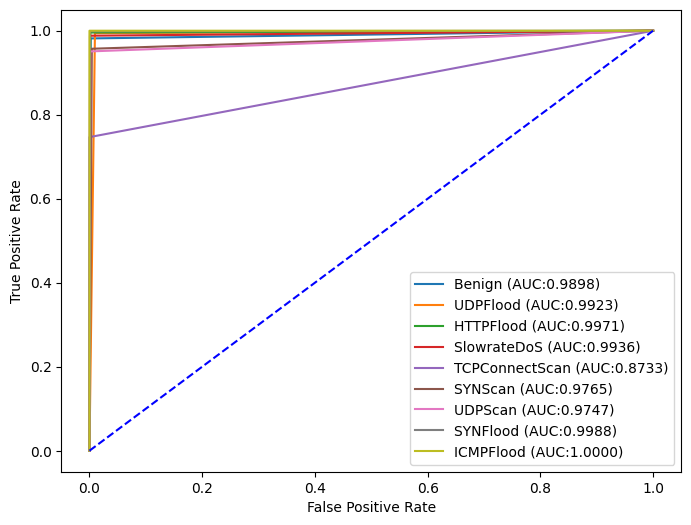

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc, roc_auc_score


target= ["Benign","UDPFlood","HTTPFlood","SlowrateDoS","TCPConnectScan","SYNScan","UDPScan","SYNFlood","ICMPFlood"]

# set plot figure size
fig, c_ax = plt.subplots(1,1, figsize = (8, 6))

# function for scoring roc auc score for multi-class
def multiclass_roc_auc_score(y_test, y_pred, average="macro"):
    lb = LabelBinarizer()
    lb.fit(y_test)
    y_test = lb.transform(y_test)
    y_pred = lb.transform(y_pred)

    for (idx, c_label) in enumerate(target):
        fpr, tpr, thresholds = roc_curve(y_test[:,idx].astype(int), y_pred[:,idx])
        c_ax.plot(fpr, tpr, label = '%s (AUC:%0.4f)'  % (c_label, auc(fpr, tpr)))
    c_ax.plot(fpr, fpr, 'b--')
    return roc_auc_score(y_test, y_pred, average=average)


print('ROC AUC score:', multiclass_roc_auc_score(y_true, y_pred))

c_ax.legend()
c_ax.set_xlabel('False Positive Rate')
c_ax.set_ylabel('True Positive Rate')
plt.show()

ROC AUC score: 0.9773362138358375


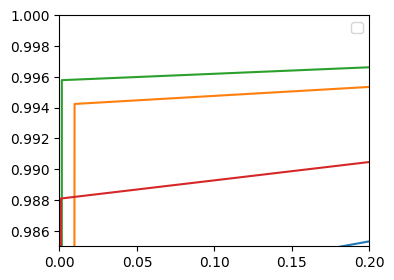

In [ ]:
from seaborn.relational import lineplot
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc, roc_auc_score


target= ["Benign","DDoS","Injection","Scanning","Malware","MITM"]

# set plot figure size
fig, c_ax = plt.subplots(1,1, figsize = (4, 3))

# function for scoring roc auc score for multi-class
def multiclass_roc_auc_score(y_test, y_pred, average="macro"):
    lb = LabelBinarizer()
    lb.fit(y_test)
    y_test = lb.transform(y_test)
    y_pred = lb.transform(y_pred)

    for (idx, c_label) in enumerate(target):
        fpr, tpr, thresholds = roc_curve(y_test[:,idx].astype(int), y_pred[:,idx])
        c_ax.plot(fpr, tpr)
    c_ax.plot(fpr, fpr, 'b--')
    return roc_auc_score(y_test, y_pred, average=average)


print('ROC AUC score:', multiclass_roc_auc_score(y_true, y_pred))

c_ax.legend()
#c_ax.set_xlabel('False Positive Rate')
#c_ax.set_ylabel('True Positive Rate')
c_ax.set(ylim=(0.985, 1.00))
c_ax.set(xlim=(0.0, 0.2))

plt.show()

In [ ]:
model.save("model.h5")

In [ ]:
def get_flops(model_h5_path):
    session = tf.compat.v1.Session()
    graph = tf.compat.v1.get_default_graph()


    with graph.as_default():
        with session.as_default():
            model = tf.keras.models.load_model(model_h5_path)

            run_meta = tf.compat.v1.RunMetadata()
            opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

            # We use the Keras session graph in the call to the profiler.
            flops = tf.compat.v1.profiler.profile(graph=graph,
                                                  run_meta=run_meta, cmd='op', options=opts)

            return flops.total_float_ops

In [ ]:
get_flops('/content/model.h5')

Instructions for updating:
Colocations handled automatically by placer.
Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


1693